<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #16a34a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Poda de Complejidad y Control de Sobreajuste ✂️🛡️
      </h1>
      <p style="margin: 6px 0 0 0; color: #16a34a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Cost-Complexity Pruning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #15803d; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #16a34a; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/02_Poda_y_Control_de_Complejidad.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El problema que hay que resolver: varianza sin control 🌪️

El **Cuaderno 00** de este módulo demostró el problema con números concretos: sobre la misma partición train/test (75%/25%, `random_state=42`, estratificada), un árbol **sin restricciones** entrenado sobre `abandono_clientes_telecom.csv` alcanza una exactitud de entrenamiento perfecta (**1.0000**) pero su exactitud de prueba cae a apenas **0.6928** — memorizó los 1875 clientes de entrenamiento en lugar de aprender un patrón generalizable. Un árbol mucho más simple, restringido a `max_depth=3`, no solo evita ese colapso sino que **supera** al árbol completo en el conjunto de prueba (**0.7584**), a pesar de tener solo 15 nodos frente a los cientos que produce un árbol sin límite.

Este cuaderno formaliza **por qué** limitar la complejidad de un árbol mejora su capacidad de generalizar, y presenta dos familias de técnicas para hacerlo de forma sistemática — en lugar de fijar `max_depth=3` a mano, como hizo el Cuaderno 00 — la **pre-poda** (restringir el crecimiento del árbol *mientras* se construye) y la **post-poda** (dejar crecer el árbol completo y luego recortarlo *después*, usando el criterio formal de **Poda de Complejidad de Costo**).

### 1.1 Preparación: recargando los datos y la partición del Cuaderno 00

Se repite exactamente la misma codificación de variables (mapeo binario para `factura_electronica`, `OrdinalEncoder` para `tipo_contrato`, One-Hot para `soporte_tecnico`) y la misma partición train/test (`test_size=0.25`, `random_state=42`, estratificada por `churn`) usadas en los Cuadernos 00 y 01, para que los números de este cuaderno sean directamente comparables.

In [13]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "abandono_clientes_telecom.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("Data Mining", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("..", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df_telecom = pd.read_csv(load_dataset("abandono_clientes_telecom.csv"))

df_prep = df_telecom.copy()
df_prep["factura_electronica"] = df_prep["factura_electronica"].map({"No": 0, "Si": 1})

orden_contrato = [["Mes_a_Mes", "Un_Ano", "Dos_Anos"]]
encoder_contrato = OrdinalEncoder(categories=orden_contrato)
df_prep["tipo_contrato_ord"] = encoder_contrato.fit_transform(df_prep[["tipo_contrato"]]).astype(int)

soporte_dummies = pd.get_dummies(df_prep["soporte_tecnico"], prefix="soporte").astype(int)
df_prep = pd.concat([df_prep, soporte_dummies], axis=1)

feature_cols = ["antiguedad_meses", "cargo_mensual", "cargos_totales",
                 "tipo_contrato_ord", "factura_electronica",
                 "soporte_No", "soporte_Si", "soporte_Sin_Internet"]

X = df_prep[feature_cols]
y = df_prep["churn"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

arbol_completo = DecisionTreeClassifier(random_state=42).fit(Xtr, ytr)
print(f"Arbol SIN restricciones -> train={arbol_completo.score(Xtr, ytr):.4f}  test={arbol_completo.score(Xte, yte):.4f}  "
      f"nodos={arbol_completo.tree_.node_count}  hojas={arbol_completo.get_n_leaves()}  profundidad={arbol_completo.get_depth()}")

Arbol SIN restricciones -> train=1.0000  test=0.6928  nodos=901  hojas=451  profundidad=25


---
## 2. Dos estrategias para controlar la complejidad 🧭

| | **Pre-poda** (*pre-pruning*) | **Post-poda** (*post-pruning*) |
|---|---|---|
| **Cuándo actúa** | Durante el crecimiento del árbol: impone un límite que CART respeta en cada división. | Después de crecer el árbol completo (sin restricciones): elimina ramas ya construidas. |
| **Hiperparámetros típicos** | `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`. | `ccp_alpha` (Poda de Complejidad de Costo). |
| **Ventaja** | Rápido de entrenar: el árbol nunca crece más de lo necesario. | Puede encontrar el punto óptimo de complejidad de forma más informada, porque parte de ver el árbol completo antes de decidir qué recortar. |
| **Riesgo** | Un límite mal elegido puede detener el crecimiento demasiado pronto (sesgo alto) o demasiado tarde (varianza alta) — requiere barrer varios valores. | Requiere entrenar el árbol completo primero (más costoso) y luego evaluar varios candidatos de poda. |

Las Secciones 3 y 4 exploran cada estrategia por separado sobre `abandono_clientes_telecom.csv`, y la Sección 5 las compara directamente.

---
## 3. Pre-poda: restringir el crecimiento desde el inicio ✂️

Cuatro hiperparámetros de `DecisionTreeClassifier` controlan directamente qué tan lejos puede crecer un árbol:

* **`max_depth`**: número máximo de niveles desde la raíz. Es el límite más intuitivo, y el que ya se usó (fijado a mano en 3) en el Cuaderno 00.
* **`min_samples_split`**: número mínimo de observaciones que debe tener un nodo para que CART siquiera *considere* dividirlo. Un nodo con menos observaciones que este umbral se convierte automáticamente en hoja.
* **`min_samples_leaf`**: número mínimo de observaciones que debe tener **cada** hoja resultante de una división — a diferencia de `min_samples_split` (que mira el nodo padre), esta condición se verifica en ambos hijos antes de aceptar la división.
* **`max_leaf_nodes`**: número máximo total de hojas que puede tener el árbol completo; CART crece el árbol de forma voraz (*best-first*) y se detiene apenas alcanza este límite, priorizando las divisiones que más reducen la impureza.

En lugar de fijar estos valores a mano como en el Cuaderno 00, esta sección barre un rango de valores para cada uno y usa el desempeño real en el conjunto de prueba para elegir.

In [14]:
depths = list(range(1, 16))
train_accs, test_accs, leaf_counts = [], [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xtr, ytr)
    train_accs.append(t.score(Xtr, ytr))
    test_accs.append(t.score(Xte, yte))
    leaf_counts.append(t.get_n_leaves())

resumen_depth = pd.DataFrame({"max_depth": depths, "acc_train": train_accs, "acc_test": test_accs, "hojas": leaf_counts})
print(resumen_depth.round(4).to_string(index=False))

 max_depth  acc_train  acc_test  hojas
         1     0.7109    0.7120      2
         2     0.7323    0.7072      4
         3     0.7477    0.7584      8
         4     0.7509    0.7600     16
         5     0.7669    0.7120     30
         6     0.7781    0.7536     54
         7     0.8016    0.7440     88
         8     0.8213    0.7504    128
         9     0.8437    0.7424    167
        10     0.8640    0.7392    201
        11     0.8843    0.7296    235
        12     0.8960    0.7232    270
        13     0.9195    0.6976    308
        14     0.9339    0.7024    334
        15     0.9472    0.6944    356


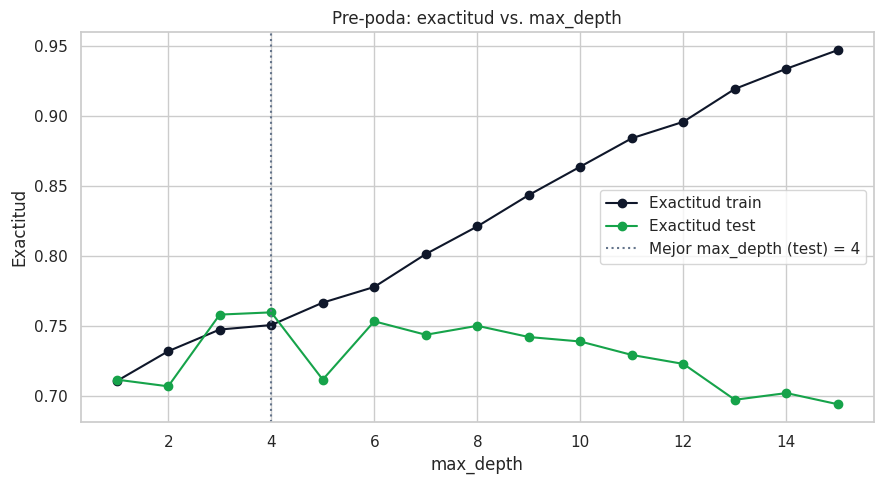

Mejor max_depth segun exactitud de prueba: 4  (acc_test=0.7600)


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_accs, marker="o", label="Exactitud train", color="#0f172a")
ax.plot(depths, test_accs, marker="o", label="Exactitud test", color="#16a34a")
mejor_depth = depths[int(np.argmax(test_accs))]
ax.axvline(mejor_depth, color="#64748b", linestyle=":", label=f"Mejor max_depth (test) = {mejor_depth}")
ax.set_xlabel("max_depth")
ax.set_ylabel("Exactitud")
ax.set_title("Pre-poda: exactitud vs. max_depth")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mejor max_depth segun exactitud de prueba: {mejor_depth}  (acc_test={max(test_accs):.4f})")

**Lectura del barrido:** la exactitud de entrenamiento crece de forma monótona con `max_depth` (de 0.7109 en profundidad 1 hasta 0.9472 en profundidad 15), mientras que la exactitud de prueba sube hasta un máximo en **`max_depth=4`** (**0.7600**) y a partir de ahí se degrada de forma irregular, cayendo por debajo de 0.70 en profundidades de 13 y 15 — la brecha train-test crece sin freno una vez pasado ese punto. Nótese que `max_depth=3` (0.7584, el valor usado en el Cuaderno 00) y `max_depth=4` (0.7600) están prácticamente empatados: la diferencia es de solo 0.0016, dentro del ruido esperable de una sola partición train/test — ambos son opciones razonables, y la Sección 6 (validación cruzada) ofrece una forma más robusta de decidir entre valores tan cercanos que fiarse de un único máximo.

In [16]:
print("Barrido de min_samples_split:")
for mss in [2, 10, 30, 60, 100]:
    t = DecisionTreeClassifier(min_samples_split=mss, random_state=42).fit(Xtr, ytr)
    print(f"  min_samples_split={mss:<4d}  train={t.score(Xtr, ytr):.4f}  test={t.score(Xte, yte):.4f}  hojas={t.get_n_leaves()}")

print("\nBarrido de min_samples_leaf:")
for msl in [1, 5, 15, 30, 60]:
    t = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42).fit(Xtr, ytr)
    print(f"  min_samples_leaf={msl:<4d}  train={t.score(Xtr, ytr):.4f}  test={t.score(Xte, yte):.4f}  hojas={t.get_n_leaves()}")

Barrido de min_samples_split:
  min_samples_split=2     train=1.0000  test=0.6928  hojas=451
  min_samples_split=10    train=0.9029  test=0.6960  hojas=253
  min_samples_split=30    train=0.8379  test=0.7216  hojas=122
  min_samples_split=60    train=0.8059  test=0.7328  hojas=67
  min_samples_split=100   train=0.7904  test=0.7472  hojas=47

Barrido de min_samples_leaf:
  min_samples_leaf=1     train=1.0000  test=0.6928  hojas=451
  min_samples_leaf=5     train=0.8656  test=0.7120  hojas=213
  min_samples_leaf=15    train=0.8053  test=0.7088  hojas=85
  min_samples_leaf=30    train=0.7755  test=0.7472  hojas=41
  min_samples_leaf=60    train=0.7621  test=0.7376  hojas=23


**Lectura:** ambos hiperparámetros muestran el mismo patrón que `max_depth` — restringir demasiado poco (`min_samples_split=2`, `min_samples_leaf=1`, los valores por defecto) reproduce el árbol sin restricciones (test=0.6928); restringir gradualmente mejora la exactitud de prueba hasta un máximo (**`min_samples_split=100` → test=0.7472**; **`min_samples_leaf=30` → test=0.7472**, exactamente el mismo valor) y usa muchas menos hojas (47 y 41 respectivamente) que el árbol sin límite (451 hojas). Ninguno de los dos, sin embargo, supera al mejor `max_depth` encontrado arriba (0.7600) — para este dataset, limitar la profundidad directamente resulta más efectivo que limitar el tamaño mínimo de los nodos.

In [17]:
print("Barrido de max_leaf_nodes:")
for mln in [2, 4, 8, 16, 32, 64]:
    t = DecisionTreeClassifier(max_leaf_nodes=mln, random_state=42).fit(Xtr, ytr)
    print(f"  max_leaf_nodes={mln:<4d}  train={t.score(Xtr, ytr):.4f}  test={t.score(Xte, yte):.4f}  profundidad={t.get_depth()}")

Barrido de max_leaf_nodes:
  max_leaf_nodes=2     train=0.7109  test=0.7120  profundidad=1
  max_leaf_nodes=4     train=0.7323  test=0.7072  profundidad=2
  max_leaf_nodes=8     train=0.7477  test=0.7584  profundidad=4
  max_leaf_nodes=16    train=0.7680  test=0.7536  profundidad=7
  max_leaf_nodes=32    train=0.7925  test=0.7488  profundidad=11
  max_leaf_nodes=64    train=0.8267  test=0.7488  profundidad=21


**Lectura:** `max_leaf_nodes=8` alcanza el mejor resultado de este barrido (test=0.7584, con 8 hojas — la misma exactitud y el mismo número de hojas que el árbol `max_depth=3` del Cuaderno 00, aunque **no** es el mismo árbol: `max_leaf_nodes` crece de forma voraz *best-first*, priorizando en cada paso la división que más reduce la impureza sin importar el nivel, así que termina con profundidad 4 en lugar de 3 — una coincidencia en el resultado final, no en la estructura), y `max_leaf_nodes=16` (test=0.7536, profundidad 7) queda algo más lejos. Entre los cuatro hiperparámetros de pre-poda explorados, **`max_depth=4`** produjo la mejor exactitud de prueba individual (0.7600) de toda la sección, así que se adopta como el árbol de referencia de pre-poda para la comparación de la Sección 5.

In [18]:
arbol_pre_podado = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xtr, ytr)
print(f"Arbol pre-podado (max_depth=4) -> train={arbol_pre_podado.score(Xtr, ytr):.4f}  test={arbol_pre_podado.score(Xte, yte):.4f}  "
      f"nodos={arbol_pre_podado.tree_.node_count}  hojas={arbol_pre_podado.get_n_leaves()}  profundidad={arbol_pre_podado.get_depth()}")

Arbol pre-podado (max_depth=4) -> train=0.7509  test=0.7600  nodos=31  hojas=16  profundidad=4


---
## 4. Post-poda: Poda de Complejidad de Costo (*Cost-Complexity Pruning*) ✂️📐

La pre-poda impone un límite *antes* de ver el árbol completo. La **Poda de Complejidad de Costo** invierte el orden: deja crecer el árbol sin ninguna restricción (como el `arbol_completo` de la Sección 1, con 901 nodos) y luego recorta las ramas que menos aportan, guiada por una función de costo explícita:

$$R_\alpha(T) = R(T) + \alpha \, |T|$$

donde $R(T)$ es el error (de clasificación, acumulado sobre la impureza) del árbol $T$ sobre los datos de entrenamiento, $|T|$ es el número de hojas terminales de $T$, y $\alpha \geq 0$ (`ccp_alpha`) es un parámetro de penalización: cuanto mayor $\alpha$, más caro resulta cada hoja adicional y más agresiva es la poda resultante. Con $\alpha=0$ no hay penalización y $R_\alpha(T)=R(T)$ — el árbol completo sin podar es óptimo. Con $\alpha$ suficientemente grande, el costo de cualquier hoja adicional supera su beneficio y el árbol se reduce a un único nodo (la clase mayoritaria).

`scikit-learn` no exige elegir $\alpha$ a ciegas: el método `cost_complexity_pruning_path()` devuelve, para el árbol completo ya entrenado, la secuencia exacta de valores de $\alpha$ en los que la poda óptima cambia de estructura (cada $\alpha$ candidato corresponde a colapsar exactamente una subrama).

In [19]:
arbol_para_podar = DecisionTreeClassifier(random_state=42)
path = arbol_para_podar.cost_complexity_pruning_path(Xtr, ytr)
ccp_alphas = path.ccp_alphas

print(f"Valores candidatos de alpha: {len(ccp_alphas)}")
print(f"Rango: {ccp_alphas.min():.6f}  a  {ccp_alphas.max():.6f}")

Valores candidatos de alpha: 185
Rango: 0.000000  a  0.045336


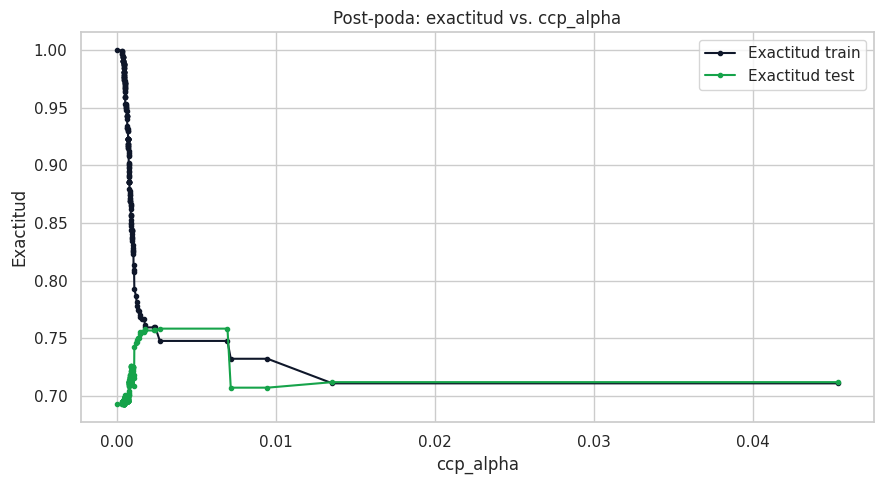

Mejor alpha segun exactitud de prueba: 0.001778  (acc_test=0.7584, hojas=11)


In [20]:
arboles_podados = [DecisionTreeClassifier(random_state=42, ccp_alpha=a).fit(Xtr, ytr) for a in ccp_alphas]

train_accs_alpha = [t.score(Xtr, ytr) for t in arboles_podados]
test_accs_alpha = [t.score(Xte, yte) for t in arboles_podados]
hojas_alpha = [t.get_n_leaves() for t in arboles_podados]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ccp_alphas, train_accs_alpha, marker=".", label="Exactitud train", color="#0f172a")
ax.plot(ccp_alphas, test_accs_alpha, marker=".", label="Exactitud test", color="#16a34a")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Exactitud")
ax.set_title("Post-poda: exactitud vs. ccp_alpha")
ax.legend()
plt.tight_layout()
plt.show()

mejor_idx = int(np.argmax(test_accs_alpha))
mejor_alpha = ccp_alphas[mejor_idx]
print(f"Mejor alpha segun exactitud de prueba: {mejor_alpha:.6f}  (acc_test={test_accs_alpha[mejor_idx]:.4f}, hojas={hojas_alpha[mejor_idx]})")

**Lectura del gráfico:** con $\alpha=0$ (extremo izquierdo) el árbol es el completo sin podar (train=1.0000, test=0.6928, como en la Sección 1). A medida que $\alpha$ crece, ambas curvas caen porque el árbol pierde hojas, pero **no caen a la misma velocidad**: la exactitud de entrenamiento desciende de forma suave y constante, mientras que la de prueba primero **sube** (menos sobreajuste) antes de empezar a bajar cuando la poda se vuelve demasiado agresiva y el árbol pierde señal real, no solo ruido. El máximo de la curva de prueba ocurre en **`ccp_alpha=0.001778`**, con una exactitud de prueba de **0.7584** — igual a la del árbol `max_depth=3` del Cuaderno 00, pero encontrada aquí de forma sistemática en lugar de a mano — y un árbol de apenas **11 hojas**.

In [21]:
mejor_alpha_post = ccp_alphas[mejor_idx]
arbol_post_podado = DecisionTreeClassifier(random_state=42, ccp_alpha=mejor_alpha_post).fit(Xtr, ytr)
print(f"Arbol post-podado (ccp_alpha={mejor_alpha_post:.6f}) -> train={arbol_post_podado.score(Xtr, ytr):.4f}  "
      f"test={arbol_post_podado.score(Xte, yte):.4f}  nodos={arbol_post_podado.tree_.node_count}  "
      f"hojas={arbol_post_podado.get_n_leaves()}  profundidad={arbol_post_podado.get_depth()}")

Arbol post-podado (ccp_alpha=0.001778) -> train=0.7616  test=0.7584  nodos=21  hojas=11  profundidad=6


---
## 5. Comparación directa: sin restricciones vs. pre-poda vs. post-poda 📊

In [22]:
comparacion = pd.DataFrame({
    "Modelo": ["Sin restricciones (Cuaderno 00)", "Pre-poda (max_depth=4)", "Post-poda (ccp_alpha=0.001778)"],
    "Profundidad": [arbol_completo.get_depth(), arbol_pre_podado.get_depth(), arbol_post_podado.get_depth()],
    "Nodos": [arbol_completo.tree_.node_count, arbol_pre_podado.tree_.node_count, arbol_post_podado.tree_.node_count],
    "Hojas": [arbol_completo.get_n_leaves(), arbol_pre_podado.get_n_leaves(), arbol_post_podado.get_n_leaves()],
    "Acc_train": [arbol_completo.score(Xtr, ytr), arbol_pre_podado.score(Xtr, ytr), arbol_post_podado.score(Xtr, ytr)],
    "Acc_test": [arbol_completo.score(Xte, yte), arbol_pre_podado.score(Xte, yte), arbol_post_podado.score(Xte, yte)],
})
comparacion["Brecha_train_test"] = comparacion["Acc_train"] - comparacion["Acc_test"]
display(comparacion.round(4))

,Modelo,Profundidad,Nodos,Hojas,Acc_train,Acc_test,Brecha_train_test
0,Sin restricciones (Cuaderno 00),25,901,451,1.0000,0.6928,0.3072
1,Pre-poda (max_depth=4),4,31,16,0.7509,0.7600,-0.0091
2,Post-poda (ccp_alpha=0.001778),6,21,11,0.7616,0.7584,0.0032


**Lectura de la tabla:** el árbol sin restricciones tiene la brecha train-test más grande con diferencia (**+0.3072**) — la firma clásica del sobreajuste — mientras que los dos árboles podados tienen brechas mucho más pequeñas: el pre-podado incluso queda en **-0.0091** (la exactitud de prueba supera levemente a la de entrenamiento) y el post-podado en **+0.0032**, señal de que ambos generalizan tan bien como memorizan, o mejor. Post-poda logra una exactitud de prueba muy similar a pre-poda (0.7584 vs. 0.7600) con **menos de la mitad de las hojas** (11 vs. 16) y menos de un tercio de los nodos (21 vs. 31) — un árbol más compacto y, en principio, más fácil de explicar a un equipo de negocio. Ninguna de las dos estrategias es categóricamente superior en este dataset: ambas resuelven el mismo problema de varianza que motivó este cuaderno, con un costo computacional distinto (pre-poda requiere un barrido de hiperparámetros; post-poda requiere entrenar primero el árbol completo).

---
## 6. Selección robusta de `ccp_alpha` con validación cruzada 🔁

La Sección 4 eligió `ccp_alpha=0.001778` porque maximizó la exactitud sobre **una única** partición de prueba — la misma limitación que el Módulo 02 de este curso ya señaló para cualquier hiperparámetro elegido así: una partición train/test es una muestra, y el "mejor" valor puede cambiar si se repite la partición con otra semilla. La solución, igual que en el Módulo 02, es **validación cruzada** (*k-fold cross-validation*): en lugar de evaluar cada $\alpha$ candidato una sola vez, se evalúa con `cv=5` particiones distintas dentro del conjunto de entrenamiento y se promedia, obteniendo una estimación de exactitud mucho menos sensible al azar de una sola partición. `GridSearchCV` automatiza exactamente ese barrido.

In [23]:
alpha_grid = ccp_alphas[::4]
print(f"Valores de alpha evaluados por validacion cruzada: {len(alpha_grid)}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid={"ccp_alpha": alpha_grid}, cv=cv, scoring="accuracy")
grid.fit(Xtr, ytr)

mejor_alpha_cv = grid.best_params_["ccp_alpha"]
arbol_cv = grid.best_estimator_
print(f"Mejor alpha por CV: {mejor_alpha_cv:.6f}  (accuracy promedio en CV: {grid.best_score_:.4f})")
print(f"Arbol seleccionado por CV -> test={arbol_cv.score(Xte, yte):.4f}  hojas={arbol_cv.get_n_leaves()}  profundidad={arbol_cv.get_depth()}")

Valores de alpha evaluados por validacion cruzada: 47
Mejor alpha por CV: 0.001807  (accuracy promedio en CV: 0.7227)
Arbol seleccionado por CV -> test=0.7568  hojas=10  profundidad=6


**Lectura:** la validación cruzada selecciona `ccp_alpha=0.001807` — prácticamente el mismo valor (0.001778) que había encontrado la Sección 4 con una sola partición, una diferencia de apenas 0.00003 — y el árbol resultante alcanza test=0.7568, profundidad 6 y 10 hojas, resultados casi idénticos a los de la Sección 4. En este dataset ambos enfoques coinciden, lo cual **no es garantía de que siempre lo hagan**: la validación cruzada promedia el desempeño sobre 5 particiones distintas del conjunto de entrenamiento en lugar de fiarse de una sola, así que su elección de $\alpha$ es más confiable en datasets más pequeños o más ruidosos, donde un único split podría ser optimista o pesimista por azar. La accuracy promedio de CV (0.7227) es, como es de esperar, algo menor que la accuracy de test de una sola partición (0.7568) — la CV está promediando sobre particiones más pequeñas y variadas, dando una estimación más conservadora y más honesta de lo que se puede esperar del modelo en datos nuevos.

---
## 7. Ejercicio Práctico Guiado: combinando poda y validación cruzada 📝

**Contexto:** las Secciones 3 y 4 trataron pre-poda y post-poda como alternativas separadas, pero nada impide **combinarlas**: un árbol puede tener a la vez un `max_depth` fijo y un `ccp_alpha` positivo. Vas a explorar esa combinación y a aplicar validación cruzada al árbol de pre-poda de la Sección 3 para ver si su exactitud de prueba (0.7600) se sostiene bajo un criterio más robusto.

**Tu misión:**
1. Entrena un `DecisionTreeClassifier(max_depth=6, ccp_alpha=0.0005, random_state=42)` sobre `Xtr, ytr` (combinando ambas restricciones) y calcula su exactitud de entrenamiento y de prueba, además del número de hojas.
2. Compara esos resultados con los del árbol post-podado óptimo de la Sección 4 (`arbol_post_podado`, `ccp_alpha=0.001778`, 11 hojas).
3. Usa `cross_val_score` con `cv=5` sobre un `DecisionTreeClassifier(max_depth=4, random_state=42)` (pasa el estimador sin ajustar, como exige la función) sobre `Xtr, ytr`, y calcula la media y la desviación estándar de los 5 folds.
4. Compara esa media de CV contra la exactitud de prueba de una sola partición del árbol pre-podado de la Sección 3 (0.7600) e interpreta la diferencia.

In [24]:
### TU CÓDIGO AQUÍ ###
# 1. Arbol combinado: max_depth=6 + ccp_alpha=0.0005
arbol_combinado = None
acc_train_comb = None
acc_test_comb = None
hojas_comb = None
print("Arbol combinado -> train:", acc_train_comb, " test:", acc_test_comb, " hojas:", hojas_comb)

# 2. Comparacion con el arbol post-podado de la Seccion 4
print("Post-podado (Seccion 4) -> train:", None, " test:", None, " hojas:", None)

# 3. cross_val_score sobre el arbol pre-podado (max_depth=4), cv=5
cv_scores = None
print("CV scores:", cv_scores)
print("Media CV:", None, " Desviacion estandar CV:", None)

# 4. Comparacion con el acc_test de una sola particion (Seccion 3, max_depth=4 -> 0.76)

Arbol combinado -> train: None  test: None  hojas: None
Post-podado (Seccion 4) -> train: None  test: None  hojas: None
CV scores: None
Media CV: None  Desviacion estandar CV: None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Arbol combinado: max_depth=6 + ccp_alpha=0.0005
arbol_combinado = DecisionTreeClassifier(max_depth=6, ccp_alpha=0.0005, random_state=42).fit(Xtr, ytr)
acc_train_comb = arbol_combinado.score(Xtr, ytr)
acc_test_comb = arbol_combinado.score(Xte, yte)
hojas_comb = arbol_combinado.get_n_leaves()
print("Arbol combinado -> train:", round(acc_train_comb, 4), " test:", round(acc_test_comb, 4), " hojas:", hojas_comb)

# 2. Comparacion con el arbol post-podado de la Seccion 4
print("Post-podado (Seccion 4) -> train:", round(arbol_post_podado.score(Xtr, ytr), 4),
      " test:", round(arbol_post_podado.score(Xte, yte), 4), " hojas:", arbol_post_podado.get_n_leaves())

# 3. cross_val_score sobre el arbol pre-podado (max_depth=4), cv=5
cv_scores = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=42), Xtr, ytr, cv=5, scoring="accuracy")
print("CV scores:", cv_scores.round(4))
print("Media CV:", round(cv_scores.mean(), 4), " Desviacion estandar CV:", round(cv_scores.std(), 4))
```

Resultados: el árbol combinado (`max_depth=6` + `ccp_alpha=0.0005`) alcanza `train=0.7771`, `test=0.7552` y **42 hojas** — más hojas que el post-podado óptimo de la Sección 4 (11 hojas, `test=0.7584`) y una exactitud de prueba muy similar pero ligeramente menor: combinar ambas restricciones sin buscar sistemáticamente los mejores valores de cada una no garantiza mejorar sobre la mejor estrategia individual ya encontrada — confirma que `ccp_alpha=0.0005` fue una poda demasiado suave para ese `max_depth`, dejando el árbol innecesariamente grande sin ganar exactitud a cambio.

Los 5 folds de `cross_val_score` sobre el árbol `max_depth=4` dan `[0.7387, 0.6933, 0.7280, 0.7147, 0.7067]`, con una **media de 0.7163** y una **desviación estándar de 0.0159**. Esta media de CV es notablemente **menor** que la exactitud de prueba de la Sección 3 obtenida con una sola partición (0.7600) — una diferencia de 4.4 puntos porcentuales. Esto no significa que el 0.7600 estuviera "mal": significa que esa partición específica del 25% de prueba fue, por azar, relativamente favorable para este árbol. La media de CV, al promediar sobre 5 particiones distintas del conjunto de entrenamiento, da una estimación más conservadora y más representativa de lo que puede esperarse en datos futuros — la misma lección de robustez que motivó usar `GridSearchCV` en la Sección 6 en lugar de fiarse de un único valor de `ccp_alpha`.

</details>

---
## 8. Resumen Ejecutivo del Cuaderno 02 📌

1. **La poda ataca directamente el problema de varianza demostrado en el Cuaderno 00:** un árbol sin restricciones sobreajusta (train=1.0000, test=0.6928) mientras que árboles podados generalizan mejor con una fracción de la complejidad.
2. **La pre-poda** (`max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`) limita el crecimiento del árbol *mientras* CART lo construye. Sobre este dataset, el mejor resultado individual fue **`max_depth=4`** (test=0.7600), aunque `max_depth=3`, `min_samples_leaf=30` y `max_leaf_nodes=8` dieron resultados prácticamente equivalentes (0.7472–0.7584) — la elección exacta entre valores muy cercanos importa menos que evitar los extremos (sin restricción, o restricción excesiva).
3. **La post-poda (Cost-Complexity Pruning)** deja crecer el árbol completo y lo recorta con $R_\alpha(T) = R(T) + \alpha|T|$. El mejor `ccp_alpha` encontrado sobre la curva real de este dataset fue **0.001778** (test=0.7584, solo 11 hojas) — un árbol más compacto que el mejor pre-podado (16 hojas) con exactitud casi idéntica.
4. **Ambas estrategias resuelven el mismo problema de formas distintas**, y en este dataset producen resultados comparables: la tabla de la Sección 5 confirma que ambas reducen la brecha train-test de +0.3072 (sin restricciones) a valores cercanos a cero.
5. **La validación cruzada confirma la robustez de la elección de `ccp_alpha`:** el valor seleccionado por `GridSearchCV` con `cv=5` (0.001807) coincide casi exactamente con el encontrado por una sola partición (0.001778) — aunque, como mostró el ejercicio, la accuracy promedio de CV suele ser más conservadora que la de una sola partición de prueba, y por eso es la forma más confiable de comparar hiperparámetros.
6. **Siguiente paso:** la poda mejora **un** árbol, pero no elimina su naturaleza de alta varianza — un árbol podado sigue siendo sensible a qué observaciones específicas contiene el conjunto de entrenamiento. El **Cuaderno 03** ataca el problema desde otro ángulo: en lugar de restringir un único árbol, entrena **muchos** árboles sobre distintas muestras bootstrap y promedia sus predicciones (**Bagging**), cancelando la varianza individual de cada uno.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Árboles y Bosques Aleatorios</i>
  </p>
</div>